<br>
<div align="center">
  <img src="imagens/marca assinatura hor col png.png" alt="Logo" width="300">
</div>

<h1 align="center"> Trabalho 1 (T1) </h1>

<h1 align="center">Análise Multivariada da Demanda Energética<br>e sua Relação com Variáveis Climáticas e Matriz de Geração</h1>

<br> 

**Tema:** monitoramento e análise de carga elétrica e de condições meteorológicas a partir de medições reais na Espanha

**Base utilizada:** *Hourly energy demand generation and weather: Electrical demand, generation by type, prices and weather in Spain*

**Fonte:** https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather


# Referência da base

> Jhana, N. (2019). *Hourly energy demand generation and weather* [Conjunto de dados]. repositório oficial Kaggle. https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather



# Justificativas da escolha da base de dados

  - É uma base real de dados, não são dados simulados.</li>
  - É um assunto relacionado a área do curso de Engenharia Elétrica.</li>
  - Possui variáveis fisicamente interpretáveis.</li>
  - É uma base de dados extensa o que nos permite trabalhar com leitura de dados, estatística exploratória e visualização de gráficos, que são essenciais para a dinâmica da disciplina.</li>
  - A geração energética é dada de diversas fontes, renováveis e não renováveis, que compõem a matriz energética da Espanha.</li>

  
  


# Limitações

- Parte dos dados contém valores ausentes, algumas colunas são compostas majoritariamente por zeros e há linhas repetidas, o que nos exige fazer o tratamento desses dados.</li>
- Apesar de se tratar de uma base real de dados, é necessário analisar criticamente e estatisticamente os conjuntos de dados a fim de garantir a consistência real e física dos valores dados.</li>
- Os dados meteorológicos são de 5 grandes cidades espanholas distantes entre si, limitando a captação de características climáticas de regiões rurais ou industriais que podem também impactar a demanda nacional.</li>
- A cobertura temporal é limitada, de 2015 a 2018, o que pode não refletir mudanças recentes na matriz energética espanhola.</li>





# Integrantes do grupo
* Aluno 1 — Gabriel Assunção Rios
* Aluno 2 — João Ewerton Santos Paixão
* Aluno 3 — Marcos Paulo da Silva

# Repositório do grupo

https://github.com/marcospsilv/Trabalho_2_Machine_Learning

# Convenção de cores para identificar contribuições

* <span style="color:green">**Verde**</span>: Gabriel Assunção Rios
* <span style="color:blue">**Azul**</span>: João Ewerton Santos Paixão
* <span style="color:red">**Vermelho**</span>: Marcos Paulo da Silva

# 1. Definição do problema

O presente trabalho tem como objetivo analisar o comportamento da geração/consumo e do preço de energia elétrica ao longo do tempo, buscando identificar padrões, relações e possíveis influências entre variáveis como carga total, temperatura e preço. O problema central consiste em compreender como essas variáveis se correlacionam e em que medida fatores externos, como condições climáticas, impactam a demanda e o custo da energia elétrica. A análise de geração/consumo é fundamental para:
- identificação de padrões de uso;
- planejamento energético;
- análise de previsão de consumo;
- previsão de preços.

Nesta base de dados, temos dados de geração e previsão de energia elétrica na Espanha, com resolução de 1 hora, entre janeiro de 2015 até dezembro de 2018, obtidos do [ENTSOE, um portal público](https://transparency.entsoe.eu/) de dados de Operadores de Sistemas de Transmissão (TSO) e do [TSO espanhol Red Elétrica de España](https://www.ree.es/). As variáveis incluem geração de biomassa, geração por carvão marrom, geração por gás derivado do carvão, geração por gás fóssil, geração por carvão mineral (hulha), geração por petróleo, geração por xisto betuminoso, geração por turfa, geração geotérmica, geração hidrelétrica por armazenamento bombeado(total), Consumo no bombeamento de água (hidrelétrica reversível), geração hidrelétrica a fio d’água, geração hidrelétrica de reservatório, geração por energia marinha, geração nuclear, outras fontes de geração, outras fontes renováveis, geração solar, geração a partir de resíduos, geração eólica offshore (no mar), geração eólica onshore (em terra).


Além destes, temos também dados meteorológicos de cinco das maiores cidades da Espanha: Madri, Bilbau, Valência, Barcelona e Sevilha. Os dados são de temperatura, pressão atmosférica, velocidade do vento, humidade do ar, volume de chuva e volume de neve e foram adquiridos como parte de um projeto pessoal da [Open Weather API](https://openweathermap.org/api).

Apesar da disponibilidade de dados de somente cinco cidades espanholas, é possível inferir que estes dados são suficientes para as análises que serão realizadas nesse trabalho, uma vez que a distribuição geográfica dessas cinco cidades cobre grande parte do território espanhol, como é possível observar na Figura 1, que apresenta em vermelho as províncias em que essas cinco cidades se localizam.

<div style="text-align: center;">
  <p id="figura_mapa"><b>Figura 1: Localização das províncias em que se encontram Madri, Bilbau, Valência, Barcelona e Sevilha</b></p>
  <img src="imagens/MapChart_Map.png" width="900px">
  <br>
  <small><i>Fonte: Elaborado pelo autor (2026) com uso do portal <a href="https://www.mapchart.net/spain.html" target="_blank">Map Chart</a>.</i></small>
</div>

Objetivos específicos:
- descrever a base de dados;
- tratar valores ausentes de forma tecnicamente ajustável;
- tratar valores inconsistentes fisicamente;
- investigar as distribuições e relações entre variáveis e entre os conjuntos de dados;
- discutir diferentes formas estatísticas;
- criar gráficos para visualização;
- propor como a base pode ser usada em um problema futuro de aprendizado de máquinas.




<div style="color: red;">

# 2. Leitura e Organização dos Dados

</div>

<div style="color: red;">
    
De início, é necessário importar as bibliotecas *Python* que serão utilizadas no trabalho e ler os conjuntos de dados de energia e de condições climáticas.

</div>


In [1]:
# Importando as bibliotecas necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as st
import os

In [2]:
# Lendo os dados em .csv

# Dados de energia
dataframe_energia = pd.read_csv("energy_dataset.csv", parse_dates=["time"]) # parse_dates faz o pandas tratar a primeira coluna como valores de datas reais

# Dados de condições climáticas
dataframe_clima = pd.read_csv("weather_features.csv", parse_dates=["dt_iso"]) # parse_dates faz o pandas tratar a primeira coluna como valores de datas reais

# Criando cópias dos dois dataframes para que não seja necessário carregá-los novamente em casos de alterações indevidas
df_energia = dataframe_energia.copy()
df_clima = dataframe_clima.copy()

<div style="color: red;">
    
### 2.1. Conjunto de dados de energia
Este conjunto contém os dados de geração de energia de diversas fontes na Espanha. Fontes como biomassa, carvão, combustíveis fósseis e solar, por exemplo, são apresentadas ao longo de 4 anos, hora a hora.
Além disso, são apresentados dados reais de demanda de eletricidade e do preço da energia e dados de previsão de geração solar e eólica e de demanda de eletricidade no dia seguinte.

</div>

In [3]:
print(f"Início: {df_energia['time'].min()}") # Exibindo o instante inicial da aquisição de dados
print(f"Fim:    {df_energia['time'].max()}") # Exibindo o instante final da aquisição de dados
df_energia.head(5) # Exibindo as 5 primeiras linhas dos dados de energia

Início: 2015-01-01 00:00:00+01:00
Fim:    2018-12-31 23:00:00+01:00


,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [4]:
# Conferindo se há inconsistências nos tipos de variáveis
df_energia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time                                         35064 non-null  object 
 1   generation biomass                           35045 non-null  float64
 2   generation fossil brown coal/lignite         35046 non-null  float64
 3   generation fossil coal-derived gas           35046 non-null  float64
 4   generation fossil gas                        35046 non-null  float64
 5   generation fossil hard coal                  35046 non-null  float64
 6   generation fossil oil                        35045 non-null  float64
 7   generation fossil oil shale                  35046 non-null  float64
 8   generation fossil peat                       35046 non-null  float64
 9   generation geothermal                        35046 non-null  float64
 10

In [5]:
# Convertendo o tempo "time" para um objeto de "tempo de dados" e definindo como índice

#to_datetime → 
df_energia['time'] = pd.to_datetime(df_energia['time'], utc=True)
df_energia = df_energia.set_index('time')

# Conferindo se a conversão da coluna de tempo funcionou
df_energia.info()

df_energia.head(5)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35064 entries, 2014-12-31 23:00:00+00:00 to 2018-12-31 22:00:00+00:00
Data columns (total 28 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   generation biomass                           35045 non-null  float64
 1   generation fossil brown coal/lignite         35046 non-null  float64
 2   generation fossil coal-derived gas           35046 non-null  float64
 3   generation fossil gas                        35046 non-null  float64
 4   generation fossil hard coal                  35046 non-null  float64
 5   generation fossil oil                        35045 non-null  float64
 6   generation fossil oil shale                  35046 non-null  float64
 7   generation fossil peat                       35046 non-null  float64
 8   generation geothermal                        35046 non-null  float64
 9   generation hydro pumped s

,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
time,,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,NaN,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
2015-01-01 00:00:00+00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,NaN,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2015-01-01 01:00:00+00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,NaN,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
2015-01-01 02:00:00+00:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,NaN,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
2015-01-01 03:00:00+00:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,NaN,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


<div style="color: red;">

#### 2.1.1. Identificação e tratamento de variáveis irrelevantes

É necessário conferir se existem colunas compostas somente por valores nulos (_NaN_), somente por zeros ou majoritariamente por zeros. Neste último caso, foi considerado que uma coluna é composta majoritariamente por zeros se ela apresenta mais de 99% dos valores iguais a zero.

Colunas que possuem somente valores nulos ou valores iguais a zero serão descartadas, pois serão inúteis nas análises e no aprendizado de máquina futuro. Já as colunas compostas majoritariamente por zeros também serão descartadas, porque elas podem causar instabilidades numéricas no treinamento em algoritmos lineares e em redes neurais (KUHN; JOHNSON, 2019).

</div>

In [6]:
# Conferindo quais colunas apresentam somente valores nulos (NaN)

# df_energia.columns → contém a lista de todas as colunas do DF
# isnull() → confere se cada célula é ou não é nula
# all() → analisa se TODAS as células de uma coluna é nula
# tolist() → converte o objeto em lista comum para exibição
totalmente_nulas = df_energia.columns[df_energia.isnull().all()].tolist()

print(f"– Colunas com 100% de valores nulos (NaN): {totalmente_nulas}")

# 1. Identificando quais colunas têm apenas o valor 0
colunas_so_zero = df_energia.columns[(df_energia == 0).all()].tolist()

print(f"  ")
print(f"– Colunas que contêm apenas zeros: {colunas_so_zero}")


# Conferindo quais colunas apresentam mais de 95% dos valores iguais a zero (0)

# Calculando a proporção de zeros em cada coluna
proporcao_zeros = (df_energia == 0).mean()

# Filtrando colunas que têm mais de 95% de zeros
colunas_muitos_zeros = proporcao_zeros[proporcao_zeros > 0.99].index.tolist()

print(f"  ")
print(f"– Colunas com mais de 99% de valores iguais a zero (0): {colunas_muitos_zeros}")

– Colunas com 100% de valores nulos (NaN): ['generation hydro pumped storage aggregated', 'forecast wind offshore eday ahead']
  
– Colunas que contêm apenas zeros: []
  
– Colunas com mais de 99% de valores iguais a zero (0): ['generation fossil coal-derived gas', 'generation fossil oil shale', 'generation fossil peat', 'generation geothermal', 'generation marine', 'generation wind offshore']


In [7]:
# Descartando as colunas "inúteis"

# Combinando as três listas em uma só
# set() → cria um conjunto evitando possíveis duplicidades
colunas_para_remover = list(set(totalmente_nulas + colunas_so_zero + colunas_muitos_zeros))

# Removendo as colunas do conjuntos de dados de energia
# drop → remove linhas ou colunas de um dataframe
# 'errors=ignore' → é uma segurança extra caso uma coluna já tenha sido removida
df_energia = df_energia.drop(columns=colunas_para_remover, errors='ignore')

# Exibindo o resultado da limpeza
print(f"– Limpeza concluída!")
print(f"– Total de colunas removidas: {len(colunas_para_remover)}")
print(f"– Colunas restantes no DataFrame: {df_energia.shape[1]}")

– Limpeza concluída!
– Total de colunas removidas: 8
– Colunas restantes no DataFrame: 20


<div style="color: red;">
    
Ademais, as colunas que possuem dados de predição ("_forecast_") de carga total, energia solar e energia eólica serão descartadas, pois são irrelevantes para as análises realizadas nesse trabalho.

</div>

In [8]:
# Descartando as colunas de predição

# axis=1 == axis=columns → remove colunas
df_energia = df_energia.drop(['total load forecast', 'forecast solar day ahead',
                            'forecast wind onshore day ahead'], axis=1)

# Exibindo o resultado da limpeza
print(f"Limpeza concluída!")
print(f"Colunas restantes no DataFrame: {df_energia.shape[1]}")

Limpeza concluída!
Colunas restantes no DataFrame: 17


In [9]:
# Informações sobre o dataframe de dados de energia
df_energia.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35064 entries, 2014-12-31 23:00:00+00:00 to 2018-12-31 22:00:00+00:00
Data columns (total 17 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   generation biomass                           35045 non-null  float64
 1   generation fossil brown coal/lignite         35046 non-null  float64
 2   generation fossil gas                        35046 non-null  float64
 3   generation fossil hard coal                  35046 non-null  float64
 4   generation fossil oil                        35045 non-null  float64
 5   generation hydro pumped storage consumption  35045 non-null  float64
 6   generation hydro run-of-river and poundage   35045 non-null  float64
 7   generation hydro water reservoir             35046 non-null  float64
 8   generation nuclear                           35047 non-null  float64
 9   generation other         

<div style="color: red;">
    
#### 2.1.2. Tratamento de valores ausentes (NaNs) e de linhas duplicadas
Para limpeza dos dados, precisa-se conferir se há linhas duplicadas e valores ausentes no conjunto de dados de energia.

</div>


In [10]:
# Contando os nulos em cada coluna

# isnull() → identifica se o valor é NaN
# sum() → soma a quantidade de nulos por coluna
nulos_por_coluna = df_energia.isnull().sum()

# Exibindo as colunas que possuem pelo menos um valor nulo
print("– Quantidade de NaNs por coluna:")
print(nulos_por_coluna[nulos_por_coluna > 0])

# Exibindo o valor total de valores nulos no dataframe de energia

# .sum().sum() → soma primeiro a quantidade de nulos por coluna e depois soma o número de nulos por coluna
total_geral_nulos = df_energia.isnull().sum().sum()
print(f"   ")
print(f"– Total de valores nulos no DataFrame: {total_geral_nulos}")

# Conferindo se há linhas duplicadas

# duplicated() → confere se a linha é igual à linha anterior
total_duplicadas = df_energia.duplicated().sum()
print(f"   ")
print(f"– Há {total_duplicadas} linhas duplicadas nas colunas.")

– Quantidade de NaNs por coluna:
generation biomass                             19
generation fossil brown coal/lignite           18
generation fossil gas                          18
generation fossil hard coal                    18
generation fossil oil                          19
generation hydro pumped storage consumption    19
generation hydro run-of-river and poundage     19
generation hydro water reservoir               18
generation nuclear                             17
generation other                               18
generation other renewable                     18
generation solar                               18
generation waste                               19
generation wind onshore                        18
total load actual                              36
dtype: int64
   
– Total de valores nulos no DataFrame: 292
   
– Há 0 linhas duplicadas nas colunas.


<div style="color: red;">
    
Há alguns valores ausentes nos dados de energia e, como os dados são uma série temporal, não é possível simplesmente descartar as linhas que possuem valores ausentes. Para resolver esse problema, optou-se por estimar os dados ausentes através de interpolação linear.

In [11]:
# Preenchendo os valores ausentes utilizando interpolação linear

# .interpolate() → método de interpolação para preencher valores ausentes
# inplace=True → substituí o dataframe "original" pelo novo dataframe com os NaNs preenchidos
df_energia.interpolate(method='linear', inplace=True, axis=0)

# Conferindo se todos os valores ausentes foram preenchidos
total_geral_nulos = df_energia.isnull().sum().sum()
print(f"   ")
print(f"– Total de valores nulos no DataFrame: {total_geral_nulos}")

   
– Total de valores nulos no DataFrame: 0


In [12]:
df_energia.describe().round(2)

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,total load actual,price day ahead,price actual
count,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00
mean,383.53,448.09,5622.70,4256.53,298.34,475.58,972.20,2605.53,6263.48,60.23,85.63,1432.82,269.42,5464.98,28698.28,49.87,57.88
std,85.35,354.62,2201.51,1961.99,52.52,792.31,400.71,1835.18,840.27,20.24,14.08,1679.96,50.22,3213.59,4575.83,14.62,14.20
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,18041.00,2.06,9.33
25%,333.00,0.00,4126.00,2527.00,263.00,0.00,637.00,1078.00,5759.00,53.00,73.00,71.00,240.00,2933.00,24807.00,41.49,49.35
50%,367.00,509.00,4969.50,4475.00,300.00,68.00,906.00,2165.00,6564.00,57.00,88.00,616.00,279.00,4849.50,28902.00,50.52,58.02
75%,433.00,757.00,6429.00,5839.00,330.00,616.00,1250.00,3758.00,7025.00,80.00,97.00,2579.00,310.00,7399.50,32194.25,60.53,68.01
max,592.00,999.00,20034.00,8359.00,449.00,4523.00,2000.00,9728.00,7117.00,106.00,119.00,5792.00,357.00,17436.00,41015.00,101.99,116.80


<div style="color: red;">
    
### 2.2. Conjunto de dados de condições meteorológicas
Este conjunto contém dados meteorológicos, como temperatura, pressão atmosférica, umidade e velocidade do vento, hora a hora ao longo de quatro anos em cinco grandes cidades espanholas: Valência, Madri, Bilbau, Barcelona e Sevilha.

Como os dados meteorológicos foram obtidos através do [OpenWeather](https://openweathermap.org/), os dados de temperatura são dados em Kelvin (K), os dados de pressão são dados em hectopascais (hPa), a umidade é dada em porcentagem relativa (%), a velocidade do vento é dada em metros por segundo (m/s), a direção do vento é dada em graus (°), os volumes de chuva e de neve são dados em milímetros (mm) e a cobertura de nuvens é dada em percentual de nebulosidade.

In [13]:
# Gerando uma lista das cidades presentes no conjunto de dados
cidades = df_clima['city_name'].unique().tolist()

print(f"– Cidades presentes no conjunto de dados:{cidades}")
print(f"  ")
print(f"Início: {df_clima['dt_iso'].min()}") # Exibindo o instante inicial da aquisição de dados
print(f"Fim:    {df_clima['dt_iso'].max()}") # Exibindo o instante final da aquisição de dados
print(f"  ")
df_clima.head(5)

– Cidades presentes no conjunto de dados:['Valencia', 'Madrid', 'Bilbao', ' Barcelona', 'Seville']
  
Início: 2015-01-01 00:00:00+01:00
Fim:    2018-12-31 23:00:00+01:00
  


,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n


In [14]:
# Conferindo se há inconsistências nos tipos de variáveis
df_clima.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178396 entries, 0 to 178395
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   dt_iso               178396 non-null  object 
 1   city_name            178396 non-null  object 
 2   temp                 178396 non-null  float64
 3   temp_min             178396 non-null  float64
 4   temp_max             178396 non-null  float64
 5   pressure             178396 non-null  int64  
 6   humidity             178396 non-null  int64  
 7   wind_speed           178396 non-null  int64  
 8   wind_deg             178396 non-null  int64  
 9   rain_1h              178396 non-null  float64
 10  rain_3h              178396 non-null  float64
 11  snow_3h              178396 non-null  float64
 12  clouds_all           178396 non-null  int64  
 13  weather_id           178396 non-null  int64  
 14  weather_main         178396 non-null  object 
 15  weather_descripti

<div style="color: red;">

É necessário que todas as colunas numéricas possuam o mesmo tipo de variável, logo as colunas com valores inteiros (_int64_) são convertidas para _float64_.

In [15]:
# Alterando as colunas com tipo int64 para float64
# Seleciona colunas inteiras e as converte
# Seleciona automaticamente tudo que for número inteiro e converte
df_clima = df_clima.astype({col: 'float64' for col in df_clima.select_dtypes('int64').columns})

df_clima.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178396 entries, 0 to 178395
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   dt_iso               178396 non-null  object 
 1   city_name            178396 non-null  object 
 2   temp                 178396 non-null  float64
 3   temp_min             178396 non-null  float64
 4   temp_max             178396 non-null  float64
 5   pressure             178396 non-null  float64
 6   humidity             178396 non-null  float64
 7   wind_speed           178396 non-null  float64
 8   wind_deg             178396 non-null  float64
 9   rain_1h              178396 non-null  float64
 10  rain_3h              178396 non-null  float64
 11  snow_3h              178396 non-null  float64
 12  clouds_all           178396 non-null  float64
 13  weather_id           178396 non-null  float64
 14  weather_main         178396 non-null  object 
 15  weather_descripti

In [16]:
# Convertendo o tempo "time" para um objeto de "tempo de dados" e definindo como índice

#to_datetime →
df_clima['time'] = pd.to_datetime(df_clima['dt_iso'], utc=True)
df_clima = df_clima.drop(['dt_iso'], axis=1)
df_clima = df_clima.set_index('time')

df_clima.head(5)

C:\Users\marqu\AppData\Local\Temp\ipykernel_8476\3791859766.py:4: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df_clima['time'] = pd.to_datetime(df_clima['dt_iso'], utc=True, infer_datetime_format=True)


,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
time,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,Valencia,270.475,270.475,270.475,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n
2015-01-01 00:00:00+00:00,Valencia,270.475,270.475,270.475,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n
2015-01-01 01:00:00+00:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n
2015-01-01 02:00:00+00:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n
2015-01-01 03:00:00+00:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n


<div style="color: red;">
    
#### 2.2.1. Identificação e tratamento de variáveis irrelevantes

Assim como foi feito com o conjunto de dados de energia, as colunas compostas somente por valores nulos(_NaN_), somente por zeros ou majoritariamente por zeros devem ser desacartadas.

In [17]:
# Conferindo quais colunas apresentam somente valores nulos (NaN)

# df_energia.columns → contém a lista de todas as colunas do DF
# isnull() → confere se cada célula é ou não é nula
# all() → analisa se TODAS as células de uma coluna é nula
# tolist() → converte o objeto em lista comum para exibição
totalmente_nulas = df_clima.columns[df_clima.isnull().all()].tolist()

print(f"– Colunas com 100% de valores nulos (NaN): {totalmente_nulas}")

# 1. Identificando quais colunas têm apenas o valor 0
colunas_so_zero = df_clima.columns[(df_clima == 0).all()].tolist()

print(f"  ")
print(f"– Colunas que contêm apenas zeros: {colunas_so_zero}")


# Conferindo quais colunas apresentam mais de 95% dos valores iguais a zero (0)

# Calculando a proporção de zeros em cada coluna
proporcao_zeros = (df_clima == 0).mean()

# Filtrando colunas que têm mais de 95% de zeros
colunas_muitos_zeros = proporcao_zeros[proporcao_zeros > 0.95].index.tolist()

print(f"  ")
print(f"– Colunas com mais de 95% de valores iguais a zero (0): {colunas_muitos_zeros}")

– Colunas com 100% de valores nulos (NaN): []
  
– Colunas que contêm apenas zeros: []
  
– Colunas com mais de 95% de valores iguais a zero (0): ['rain_3h', 'snow_3h']


In [18]:
df_clima.describe().round(2)

,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id
count,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00
mean,289.62,288.33,291.09,1069.26,68.42,2.47,166.59,0.08,0.00,0.00,25.07,759.83
std,8.03,7.96,8.61,5969.63,21.90,2.10,116.61,0.40,0.01,0.22,30.77,108.73
min,262.24,262.24,262.24,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,200.00
25%,283.67,282.48,284.65,1013.00,53.00,1.00,55.00,0.00,0.00,0.00,0.00,800.00
50%,289.15,288.15,290.15,1018.00,72.00,2.00,177.00,0.00,0.00,0.00,20.00,800.00
75%,295.15,293.73,297.15,1022.00,87.00,4.00,270.00,0.00,0.00,0.00,40.00,801.00
max,315.60,315.15,321.15,1008371.00,100.00,133.00,360.00,12.00,2.32,21.50,100.00,804.00


<div style="color: red;">

No que diz respeito à coluna "snow_3h", optou-se por sua permanência no conjunto de dados devido ao seu possível impacto direto na demanda energética, já que a ocorrência de neve está relacionada a quedas bruscas de temperatura e, consequentemente, mudanças no comportamento de consumo. Vale mencionar que o desvio padrão (std) de "snow_3h" é baixo, porém relativamente próximo do desvio padrão de "rain_1h", indicando sua possível relevância nas análises deste trabalho.

<div style="color: red;">

Além disso, as colunas que possuem informações climáticas qualitativas serão descartadas.

In [19]:
# Descartando as colunas com informações de clima qualitativas
df_clima = df_clima.drop(['weather_main', 'weather_id', 
                              'weather_description', 'weather_icon'], axis=1)

# Exibindo o resultado da limpeza
print(f"Limpeza concluída!")
print(f"Colunas restantes no DataFrame: {df_clima.shape[1]}")

Limpeza concluída!
Colunas restantes no DataFrame: 12


<div style="color: red;">
    
#### 2.2.2. Tratamento de valores ausentes (NaNs) e de linhas duplicadas
Para limpeza dos dados, precisa-se conferir se há linhas duplicadas e valores ausentes no conjunto de dados meteorológicos.



In [20]:

# Contando os nulos em cada coluna

# isnull() → identifica se o valor é NaN
# sum() → soma a quantidade de nulos por coluna
nulos_por_coluna = df_clima.isnull().sum()

# Exibindo as colunas que possuem pelo menos um valor nulo
print("– Quantidade de NaNs por coluna:")
print(nulos_por_coluna[nulos_por_coluna > 0])

# Exibindo o valor total de valores nulos no dataframe de energia

# .sum().sum() → soma primeiro a quantidade de nulos por coluna e depois soma o número de nulos por coluna
total_geral_nulos = df_clima.isnull().sum().sum()
print(f"   ")
print(f"– Total de valores nulos no DataFrame: {total_geral_nulos}")

# Conferindo se há linhas duplicadas

# duplicated() → confere se a linha é igual à linha anterior
total_duplicadas = df_clima.duplicated().sum()
print(f"   ")
print(f"– Há {total_duplicadas} linhas duplicadas nas colunas.")

– Quantidade de NaNs por coluna:
Series([], dtype: int64)
   
– Total de valores nulos no DataFrame: 0
   
– Há 13038 linhas duplicadas nas colunas.


<div style="color: red;">

Nesse caso, não há valores ausentes nos dados. Entretanto, há 21 linhas duplicadas que devem ser descartadas.

In [21]:
# Descartando as linhas duplicadas
df_clima_2 = df_clima.drop_duplicates(inplace=True)

In [22]:
# Conferindo se as linhas repetidas foram descartadas

# duplicated() → confere se a linha é igual à linha anterior
total_duplicadas = df_clima.duplicated().sum()
print(f"   ")
print(f"– Há {total_duplicadas} linhas duplicadas nas colunas.")

   
– Há 0 linhas duplicadas nas colunas.


<div style="color: red;">

#### 2.2.3. Tratamento de inconsistências

In [23]:
df_clima.describe().round(2)

,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all
count,165358.00,165358.00,165358.00,165358.00,165358.00,165358.00,165358.00,165358.00,165358.00,165358.00,165358.00
mean,289.74,288.39,291.29,1074.19,67.68,2.49,167.09,0.07,0.00,0.01,24.42
std,8.01,7.93,8.63,6200.48,21.77,2.11,116.90,0.40,0.01,0.23,30.20
min,262.24,262.24,262.24,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,283.84,282.63,285.14,1014.00,52.00,1.00,56.00,0.00,0.00,0.00,0.00
50%,289.15,288.15,290.25,1018.00,71.00,2.00,180.00,0.00,0.00,0.00,20.00
75%,295.32,294.15,297.15,1022.00,87.00,4.00,270.00,0.00,0.00,0.00,40.00
max,315.60,315.15,321.15,1008371.00,100.00,133.00,360.00,12.00,2.32,21.50,100.00


<div style="color: red;">

O resumo estatístico do conjunto de dados meteorológicos apresenta algumas inconsistências graves:

<ul>
  <li><b>Pressão:</b> há o registro de valor mínimo de 0 hPa e valor máximo de 1.000.000 hPa. De acordo com a <a href="https://www.aemet.es/es/serviciosclimaticos/datos_climatologicos/valores_extremos" style="color: red;" target="_blank">Agência Estatal de Meteorologia (AEMET)</a>, a menor pressão já registrada na Espanha foi de aproximadamente 950 hPa e a maior de 1.050 hPa.</li>
  
  <li><b>Velocidade do vento:</b> o valor máximo registrado é de 133 m/s. Segundo a <a href="https://www.aemet.es/es/serviciosclimaticos/datos_climatologicos/valores_extremos" style="color: red;" target="_blank">Agência Estatal de Meteorologia (AEMET)</a>, o recorde nacional é de 248 km/h ($ \approx 68,89$ m/s), o que indica que os valores acima desse limiar no dataset são erros de medição.</li>
  
  <li><b>Chuvas:</b> os dados de <i>"rain_3h"</i> apresentam valores máximos inferiores aos de <i>"rain_1h"</i>. Fisicamente, isso é um erro lógico, pois o acumulado de 3 horas deveria, obrigatoriamente, ser igual ou superior ao acumulado de 1 hora contido no mesmo intervalo.</li>
</ul>

</div>

<Axes: xlabel='pressure'>

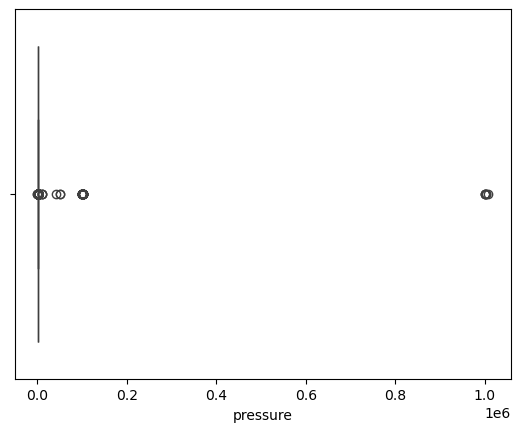

In [24]:
# Exibindo os valores inconsistentes na coluna de pressão

sns.boxplot(x=df_clima['pressure'])


<div style="color: red;">

De modo a tratar esses dados, optou-se por definir como limiar os recordes mínimo e máximo de pressão atmosférica na Espanhe e máximo de velocidade do vento, interpolando linearmente os dados de medição fora desses limiares.

In [25]:
# Definindo como NaN os valores fora do intervalo
df_clima.loc[(df_clima['pressure'] < 950), 'pressure'] = np.nan
df_clima.loc[(df_clima['pressure'] > 1050), 'pressure'] = np.nan

In [26]:
# Realiza a interpolação e salva na coluna
df_clima['pressure'] = df_clima['pressure'].interpolate(method='linear')

<Axes: xlabel='pressure'>

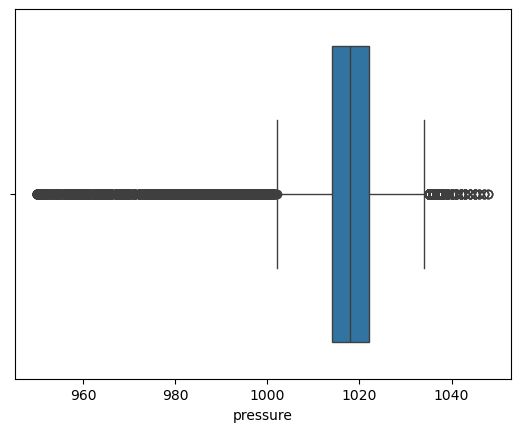

In [27]:
# Conferindo a correção na coluna de pressão atmosférica

sns.boxplot(x=df_clima['pressure'])



<Axes: xlabel='wind_speed'>

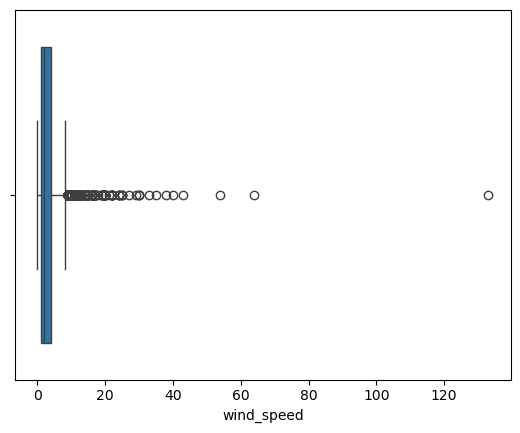

In [28]:
# Exibindo os valores inconsistentes na coluna de velocidade do vento wind_speed

sns.boxplot(x=df_clima['wind_speed'])


In [29]:
# Filtrando as velocidades do vento acima de 68,89 m/s
df_clima.loc[(df_clima['wind_speed'] > 68.89), 'wind_speed'] = np.nan

# Realiza a interpolação e salva na coluna
df_clima['wind_speed'] = df_clima['wind_speed'].interpolate(method='linear')


<Axes: xlabel='wind_speed'>

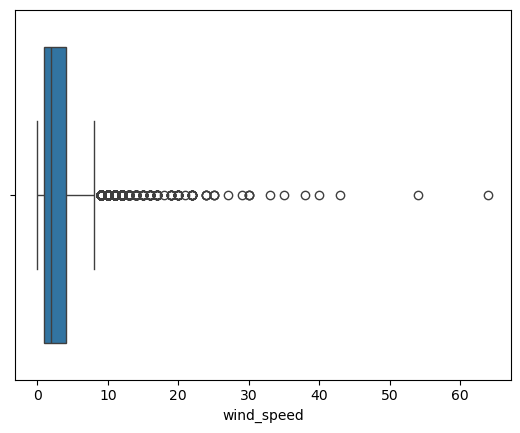

In [30]:
# Conferindo a correção na coluna de velocidade do vento

sns.boxplot(x=df_clima['wind_speed'])

<div style="color: red;">

Para corrigir o erro de medição na coluna de chuva nas últimas 3 horas ("rain_3h"), a coluna foi refeita somando-se repetidamente os últimos 3 dados da coluna "rain_3h".

In [31]:
# 2. Cria a nova coluna baseada na soma móvel das últimas 3 horas de rain_1h
df_clima['rain_3h_corrigida'] = df_clima['rain_1h'].rolling(window=3, min_periods=1).sum()

# 3. Vamos comparar as duas colunas para ver a diferença
print(df_clima[['rain_1h', 'rain_3h', 'rain_3h_corrigida']].describe())

             rain_1h        rain_3h  rain_3h_corrigida
count  165358.000000  165358.000000      165358.000000
mean        0.071166       0.000409           0.213499
std         0.395214       0.007565           0.998919
min         0.000000       0.000000           0.000000
25%         0.000000       0.000000           0.000000
50%         0.000000       0.000000           0.000000
75%         0.000000       0.000000           0.000000
max        12.000000       2.315000          36.000000


In [32]:
# 1. Deleta a coluna original que estava com erro
df_clima.drop(columns=['rain_3h'], inplace=True)

# 2. Renomeia a coluna corrigida para o nome original
df_clima.rename(columns={'rain_3h_corrigida': 'rain_3h'}, inplace=True)

In [33]:
df_clima.head(5)

,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,snow_3h,clouds_all,rain_3h
time,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,Valencia,270.475,270.475,270.475,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0
2015-01-01 01:00:00+00:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0
2015-01-01 04:00:00+00:00,Valencia,270.292,270.292,270.292,1004.0,71.0,2.0,321.0,0.0,0.0,0.0,0.0
2015-01-01 07:00:00+00:00,Valencia,274.601,274.601,274.601,1005.0,71.0,1.0,307.0,0.0,0.0,0.0,0.0
2015-01-01 10:00:00+00:00,Valencia,284.824,284.824,284.824,1006.0,55.0,1.0,255.0,0.0,0.0,0.0,0.0


In [34]:
# 1. Pegamos a lista atual de colunas
cols = list(df_clima.columns)

# 2. Removemos a 'rain_3h' da posição atual dela
cols.remove('rain_3h')

# 3. Encontramos a posição da 'rain_1h' e inserimos a 'rain_3h' logo depois (pos + 1)
pos_rain1h = cols.index('rain_1h')
cols.insert(pos_rain1h + 1, 'rain_3h')

# 4. Reaplicamos a nova ordem ao DataFrame
df_clima = df_clima[cols]

df_clima.head(10)

,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all
time,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,Valencia,270.475000,270.475000,270.475000,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0
2015-01-01 01:00:00+00:00,Valencia,269.686000,269.686000,269.686000,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0
2015-01-01 04:00:00+00:00,Valencia,270.292000,270.292000,270.292000,1004.0,71.0,2.0,321.0,0.0,0.0,0.0,0.0
2015-01-01 07:00:00+00:00,Valencia,274.601000,274.601000,274.601000,1005.0,71.0,1.0,307.0,0.0,0.0,0.0,0.0
2015-01-01 10:00:00+00:00,Valencia,284.824000,284.824000,284.824000,1006.0,55.0,1.0,255.0,0.0,0.0,0.0,0.0
2015-01-01 13:00:00+00:00,Valencia,285.050656,285.050656,285.050656,1015.0,52.0,1.0,248.0,0.0,0.0,0.0,0.0
2015-01-01 14:00:00+00:00,Valencia,285.277344,285.277344,285.277344,1025.0,50.0,1.0,242.0,0.0,0.0,0.0,0.0
2015-01-01 15:00:00+00:00,Valencia,281.024000,281.024000,281.024000,1021.0,67.0,1.0,230.0,0.0,0.0,0.0,0.0
2015-01-01 16:00:00+00:00,Valencia,282.744000,282.744000,282.744000,1035.0,58.0,1.0,226.0,0.0,0.0,0.0,0.0


In [35]:
df_clima.describe().round(2)

,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all
count,165358.00,165358.00,165358.00,165358.00,165358.00,165358.00,165358.00,165358.00,165358.00,165358.00,165358.00
mean,289.74,288.39,291.29,1016.92,67.68,2.49,167.09,0.07,0.21,0.01,24.42
std,8.01,7.93,8.63,9.72,21.77,2.09,116.90,0.40,1.00,0.23,30.20
min,262.24,262.24,262.24,950.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,283.84,282.63,285.14,1014.00,52.00,1.00,56.00,0.00,0.00,0.00,0.00
50%,289.15,288.15,290.25,1018.00,71.00,2.00,180.00,0.00,0.00,0.00,20.00
75%,295.32,294.15,297.15,1022.00,87.00,4.00,270.00,0.00,0.00,0.00,40.00
max,315.60,315.15,321.15,1048.00,100.00,64.00,360.00,12.00,36.00,21.50,100.00


<div style="color: red;">
    
&nbsp;
### 2.3. Unindo os dois conjuntos de dados em um único dataset

Com o objetivo de avaliar a influência dos dados de condições meteorológicas na predição da demanda energética, os dados de energia são mesclados aos dados meteorológicos.

In [36]:
# Separando df_clima em 5 dataframes, um por cidade

# Agrupa as linhas do dataframe original com base nos nomes (valores) da coluna "city_name" e o resultado é armazenado em cada um dos subdataframes
df_1, df_2, df_3, df_4, df_5 = [x for _, x in df_clima.groupby('city_name')]

# Agrupa os 5 dataframes em uma lista
dataframes_clima = [df_1, df_2, df_3, df_4, df_5]

In [37]:
# Unindo os dois conjuntos de dados

df_final = df_energia # Cria o dataframe principal utilizando os dados de energia

for df in dataframes_clima: # Loop para passar pelos 5 dataframes criados no passo anterior
    
    city = df['city_name'].unique() # unique() -> retorna um array com os valores únicos dessa coluna (nome de cada cidade)
    
    city_str = str(city).replace("'", "").replace('[', '').replace(']', '').replace(' ', '') # Limpa possíveis simbolos como aspas, colchetes e espaços
    
    df = df.add_suffix('_{}'.format(city_str)) # Adiciona um sufixo com o nome de cidade a cada coluna do dataframe

    # Une os dados de energia aos dados de condicoes climaticas em "df_ final"
    # on=['time'] -> garante a sincronia entre os horários dos dois dataframes
    # how='outer' -> garante a junção dos dados mesmo que existam linhas não mutuamente existentes nos dois dataframes: PODE CRIAR MAIS NANS
    df_final = df_final.merge(df, on=['time'], how='outer') 
    
    df_final = df_final.drop('city_name_{}'.format(city_str), axis=1) # Remove a coluna com os nomes da cidade, agora é irrelevante

df_final.columns # Exibe as colunas no dataframe final

Index(['generation biomass', 'generation fossil brown coal/lignite',
       'generation fossil gas', 'generation fossil hard coal',
       'generation fossil oil', 'generation hydro pumped storage consumption',
       'generation hydro run-of-river and poundage',
       'generation hydro water reservoir', 'generation nuclear',
       'generation other', 'generation other renewable', 'generation solar',
       'generation waste', 'generation wind onshore', 'total load actual',
       'price day ahead', 'price actual', 'temp_Barcelona',
       'temp_min_Barcelona', 'temp_max_Barcelona', 'pressure_Barcelona',
       'humidity_Barcelona', 'wind_speed_Barcelona', 'wind_deg_Barcelona',
       'rain_1h_Barcelona', 'rain_3h_Barcelona', 'snow_3h_Barcelona',
       'clouds_all_Barcelona', 'temp_Bilbao', 'temp_min_Bilbao',
       'temp_max_Bilbao', 'pressure_Bilbao', 'humidity_Bilbao',
       'wind_speed_Bilbao', 'wind_deg_Bilbao', 'rain_1h_Bilbao',
       'rain_3h_Bilbao', 'snow_3h_Bilbao', 'clo

In [38]:
# Conferindo se há valores ausentes e linhas duplicadas no dataframe final

print('Há {} valores ausentes (NaNs) em df_final.'
      .format(df_final.isnull().values.sum()))

temp_final = df_final.duplicated(keep='first').sum()

print('\nHá {} linhas duplicadas em df_energy.'
      .format(temp_final))

Há 109582 valores ausentes (NaNs) em df_final.

Há 0 linhas duplicadas em df_energy.


# 3. Aplicação de técnicas de regressão

In [ ]:

def preparar_dados_predicao(df_clima):
    df_clima_ml = df_clima.copy()

    # 1. Variáveis Cíclicas do Tempo
    df_clima_ml["hour_sin"] = np.sin(2 * np.pi * df_clima_ml.index.hour / 24.0)
    df_clima_ml["hour_cos"] = np.cos(2 * np.pi * df_clima_ml.index.hour / 24.0)
    df_clima_ml["dayofweek"] = df_clima_ml.index.dayofweek
    df_clima_ml["month"] = df_clima_ml.index.month

    # ==============================================================================
    # CORREÇÃO PONTO 2: Ajuste dos nomes das colunas com espaços (padrão do Kaggle)
    # ==============================================================================
    col_target = "total load actual"
    col_solar = "forecast solar day ahead"
    col_wind = "forecast wind onshore day ahead"
    col_forecast = "total load forecast"

    # 2. Definição do Target: Demanda do dia seguinte (24 horas à frente)
    df_clima_ml["target_demanda_amanha"] = df_clima_ml[col_target].shift(-24)

    # 3. Criação de Lags (Passado Recente) para dar dinâmica ao modelo
    df_clima_ml["load_lag_0"] = df_clima_ml[col_target]
    df_clima_ml["load_lag_24"] = df_clima_ml[col_target].shift(24)
    df_clima_ml["load_lag_168"] = df_clima_ml[col_target].shift(168)

    # 4. Seleção de Features preditoras
    features = [
        "hour_sin",
        "hour_cos",
        "dayofweek",
        "month",
        "load_lag_0",
        "load_lag_24",
        "load_lag_168",
        col_solar,
        col_wind,
        col_forecast,
    ]

    # Preencher pequenos valores nulos pontuais antes do descarte das bordas
    df_clima_ml[features] = df_clima_ml[features].ffill().bfill()

    # Remover valores nulos gerados pelos shifts
    df_clima_ml = df_clima_ml.dropna(subset=["target_demanda_amanha"] + features)

    X = df_clima_ml[features]
    y = df_clima_ml["target_demanda_amanha"]

    return X, y


# Execução da sua função com o DataFrame carregado acima
X, y = preparar_dados_predicao(df)

# ==============================================================================
# CORREÇÃO PONTO 3: Conclusão das linhas finais que estavam truncadas
# ==============================================================================
limite_treino = int(len(X) * 0.8)
X_train, X_test = X.iloc[:limite_treino], X.iloc[limite_treino:]
y_train, y_test = y.iloc[:limite_treino], y.iloc[limite_treino:]

# Confirmação dos tamanhos dos conjuntos gerados
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

<div style="color: green;">
Independência (verificação simples)

<div style="color: green;">

#### Análise de Dependência:
A utilização do Mapa de Calor (Heatmap) baseado no coeficiente de correlação de Pearson permite identificar matematicamente como as variáveis do sistema elétrico e climático interagem entre si. O mapa traduz a força da relação linear entre duas variáveis em um valor que varia de -1 a +1:
####  Correlação Próxima de +1:
Indica uma relação direta forte. 
#### Próxima de -1:
Indica uma relação inversa. Se uma variável aumenta, a outra diminui proporcionalmente.
#### Correlação Próxima de 0: 
Indica que não há relação linear entre as variáveis.

<div style="color: green;">

#### Análise do gráfico:
- É possível observar que a correlação mais forte é entre a temperatura e a umidade, ela é uma correlação negativa, o que significa que quando a temperatura sobe a umidade tende a descer.É posivel observar que não existe nenhuma outra correlação mais forte entre as outras variáveis.

<div style="color: green;">

## 3.5 Série temporal

<div style="color: green;">

#### Análise de Séries Temporais: Evolução Histórica do Preço
A análise da evolução do preço da energia ao longo do tempo é o ponto de partida para compreender a dinâmica do mercado elétrico. A utilização de um gráfico de linhas temporal justifica-se pelos seguintes aspetos técnicos:

#### Identificação de Tendências e Ciclicidade
Diferente de uma tabela estática, o gráfico de séries temporais permite observar visualmente se o preço da energia está em uma trajetória de subida ou descida a longo prazo. No contexto do mercado espanhol, este gráfico revela a sazonalidade: padrões que se repetem anualmente (ex: preços mais altos no inverno ou verão devido à climatização) ou semanalmente.

#### Deteção de Choques e Anomalias
O gráfico de linhas é a melhor ferramenta para identificar picos de volatilidade. Momentos de crise energética, falhas no fornecimento ou eventos geopolíticos aparecem como "agulhas" no gráfico.

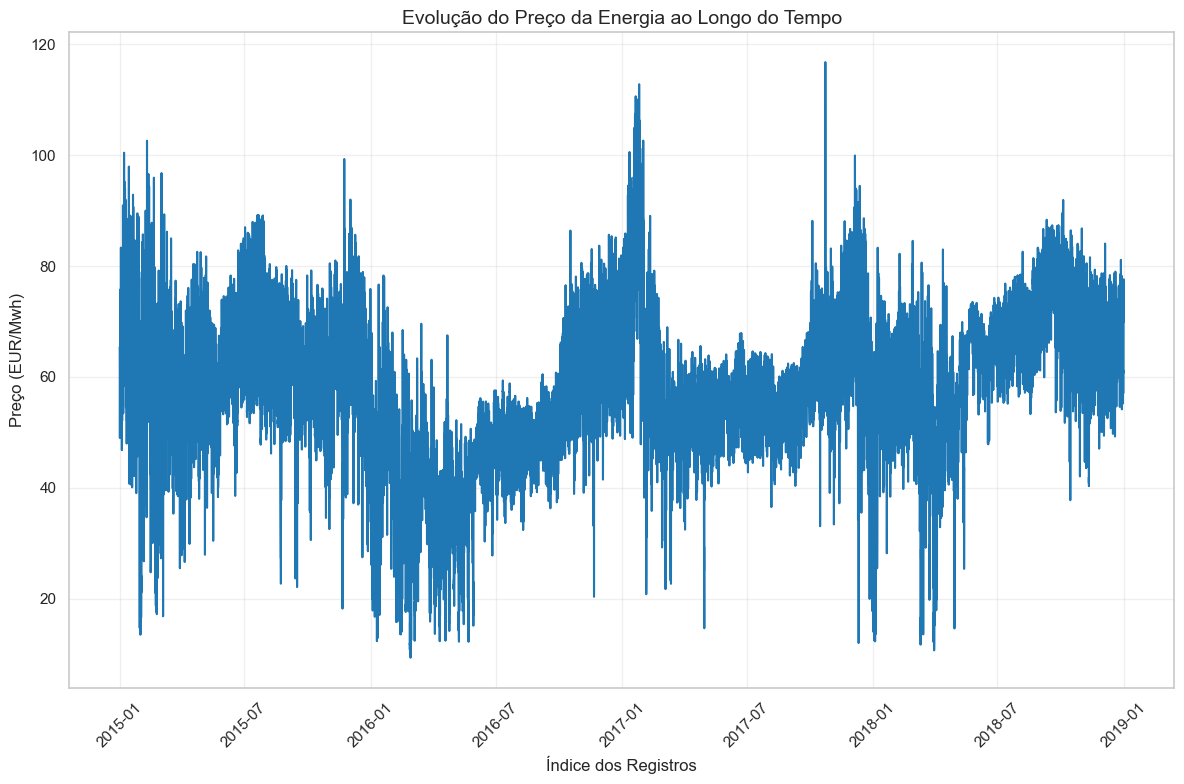

In [46]:
#import pandas as pd
#import matplotlib.pyplot as plt
#identificação automática da coluna temporal
col_tempo = None
for col in df_energia.columns:
# Verifica se 'time' ou 'date' está no nome da coluna, independente de maiúsculas
    if 'time' in col.lower() or 'date' in col.lower():
        col_tempo = col
        break

# Configuração do tamnho do gráfico
plt.figure(figsize=(12, 8))

#Lógica de Plotagem (Se encontrou data vs. Se não encontrou)

if col_tempo:
    #Converte a coluna para o formato datetime
    df_energia[col_tempo] = pd.to_datetime(df_energia[col_tempo])

    # Plota os dados, eixo X = tempo, Eixo Y = preço atual

    plt.plot(df_energia[col_tempo], df_energia['price actual'], color='tab:blue', linewidth=1)
    plt.xlabel('Data e Hora')
else:
    # Plano B: Usa o índice numérico se nenhuma coluna de tempo for detectada
    plt.plot(df_energia.index, df_energia['price actual'], color='tab:blue')
    plt.xlabel('Índice dos Registros')

# Rótulos do gráfico
plt.title('Evolução do Preço da Energia ao Longo do Tempo', fontsize=14)
plt.ylabel('Preço (EUR/Mwh)')

# Ajustes de legibilidade
plt.xticks(rotation=45) # aotaciona as datas para não sobrepor o texto
plt.grid(True, alpha=0.3) # adiciona uma grade para facilitar a leitura de valores
plt.tight_layout()# ajusta as margens para o gráfico não cortar nas bordas

# Gerando o nome do arquivo para salvamento
filename = f"3.5_evolucao_preco.svg"
filepath = os.path.join(folder, filename)

# Salvando (sempre antes do plt.show())
plt.savefig(filepath, format='svg')

# Mostrar o resultado
plt.show()

<div style="color: green;">

#### Análise do gráfico:
- Ao longo do ano, os valores não são constantes, indicando que o preço da energia varia com o tempo, existem meses com preços mais altos e outros com preços mais baixos. Isso mostra que o mercado de energia é dinâmico e que podem ocorrer influência sazonal (clima), sol, chuva, calor, frio que interferem na geração de energia e no preço da energia. O gráfico permite identificar uma tendência geral de subida ou descida ao longo do tempo, volatilidade e possíveis padrões repetitivos.

<div style="color: green;">

## 3.6 Análise de sazonalidade da temperatura

<div style="color: green;">

#### Análise de Sazonalidade: Ciclos Mensais de Temperatura
A análise da variação sazonal da temperatura através de médias mensais agrupadas por cidade é fundamental para compreender os ciclos de longo prazo que regem o mercado de energia. A utilização desta abordagem justifica-se pelos seguintes pontos:

#### Identificação de Padrões Climáticos Regionais
Ao agrupar os dados por mês e cidade, o gráfico permite visualizar de forma clara as curvas de aquecimento e arrefecimento de cada região da Espanha. Cidades com curvas mais "acentuadas" (como Madrid ou Sevilha) indicam climas continentais com verões e invernos rigorosos, enquanto curvas mais "suaves" indicam climas costeiros. Esta distinção é crucial para o modelo, pois a carga elétrica responde de forma diferente ao clima em cada uma dessas zonas.

#### Correlação com a Demanda Energética
O gráfico justifica a inclusão da variável "Mês" como um preditor no modelo de Machine Learning. Existe uma relação física direta: nos meses onde a curva atinge o pico (julho/agosto) ou o vale (janeiro/fevereiro), a carga total do sistema elétrico tende a aumentar devido ao uso intensivo de ar condicionado e sistemas de aquecimento, respetivamente

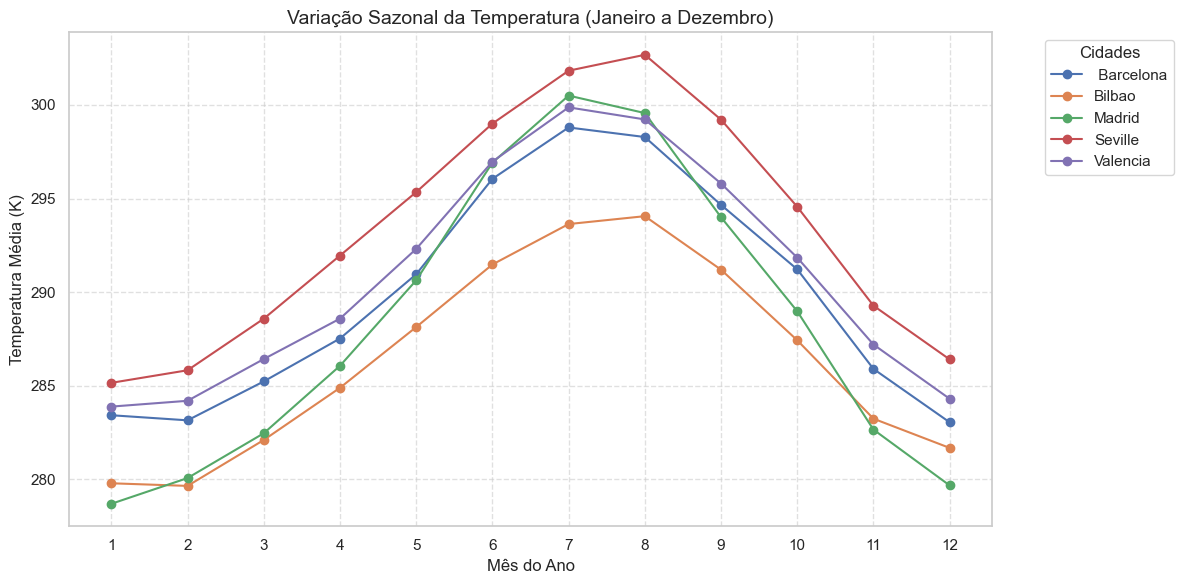

In [47]:

#import matplotlib.pyplot as plt

# Criar a coluna 'mes' a partir do índice ou da coluna de tempo
# Se o seu índice for do tipo datetime:
df_clima['mes'] = df_clima.index.month 

# SE o comando acima der erro, tente este (usando a coluna de data original):
# df_clima['mes'] = pd.to_datetime(df_clima['dt_iso']).dt.month

#Agora sim, fazemos o agrupamento e a pivotação (unstack)
df_sazonal = df_clima.groupby(['mes', 'city_name'])['temp'].mean().unstack()

#Plotagem usando Matplotlib
plt.figure(figsize=(12, 6))

for cidade in df_sazonal.columns:
    plt.plot(df_sazonal.index, df_sazonal[cidade], marker='o', label=cidade)

# Personalização técnica
plt.title('Variação Sazonal da Temperatura (Janeiro a Dezembro)', fontsize=14)
plt.xlabel('Mês do Ano', fontsize=12)
plt.ylabel('Temperatura Média (K)', fontsize=12)
plt.xticks(range(1, 13)) 
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cidades', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

# Gerando o nome do arquivo para salvamento
filename = f"3.6_variacao_sazonal_temp.svg"
filepath = os.path.join(folder, filename)

# Salvando (sempre antes do plt.show())
plt.savefig(filepath, format='svg')

plt.show()

<div style="color: green;">

#### Análise do gráfico:
- É possível observar a variação de temperatura durante os meses do ano, durante o verão na Espanha que ocorre entre o final de junho até setembro vemos temperaturas mais elevadas o que é natural. No inverno que se estende do fim de dezembro até março vemos temperaturas mais baixas que também é o natural. A diferença entre os picos de temperatura também explica por que a carga elétrica na Espanha tem picos de consumo diferentes dependendo da região e da estação do ano. Além da diferença do clima entre cidades costeiras e do interior.

<div style="color: green;">

## 3.7 Geração de energia ao longo de 24 horas

<div style="color: green;">

#### Análise de Perfil Diário: Geração Média Horária
A análise da geração média de energia ao longo das 24 horas do dia é fundamental para entender a dinâmica operacional do setor elétrico espanhol. A utilização deste gráfico justifica-se pelos seguintes aspetos técnicos e analíticos:

#### Identificação do Ciclo de Atividade Humana
O gráfico revela o "ritmo cardíaco" da sociedade. Através dele, é possível observar os períodos de rampa de subida (quando a população acorda e a indústria inicia operações) e os patamares de pico (geralmente no meio do dia e ao início da noite). Esta visualização justifica a importância da variável "hora" como o principal preditor no modelo de previsão de séries temporais.

#### Compreensão do Mix Energético e Disponibilidade
Ao agregar todas as fontes na geracao_total, o gráfico permite analisar se o sistema elétrico possui uma base de geração estável ou se depende de fontes que variam conforme o horário. Por exemplo, a presença de picos durante o dia pode estar fortemente correlacionada com a geração solar, enquanto a manutenção da geração durante a madrugada revela o papel das energias nuclear e eólica (carga de base).

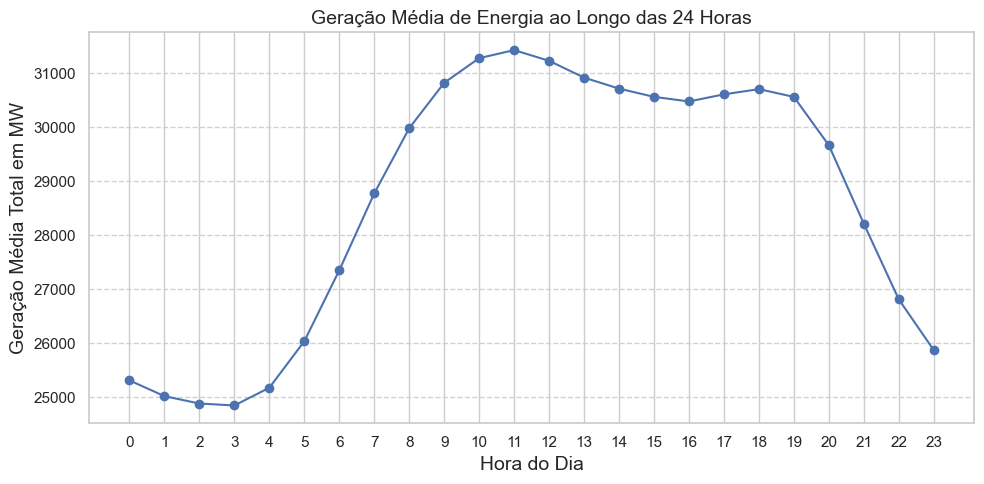

In [48]:
#import pandas as pd
#import matplotlib.pyplot as plt


#garante coluna de tempo correta

col_tempo = None
for col in df_energia.columns:
    if 'time' in col.lower() or 'date' in col.lower():
        col_tempo = col
        break
# Converte a coluna de tempo para formato datetime e define como índice
if col_tempo:
    df_energia[col_tempo] = pd.to_datetime(df_energia[col_tempo])
    df_energia = df_energia.set_index(col_tempo)
else:
        # Caso não exista coluna de tempo, usa o índice atual
    df_energia.index = pd.to_datetime(df_energia.index)

# Criar coluna de hora(0 a 23)

df_energia['hora'] = df_energia.index.hour

#Selecionar corretamente colunas de geração
colunas_geracao = [col for col in df_energia.columns if 'generation' in col.lower()]

# Soma todas as fontes de geração para obter a geração total
df_energia['geracao_total'] = df_energia[colunas_geracao].sum(axis=1)
# Agrupa os dados por hora e calcula a média da geração total
geracao_hora = df_energia.groupby('hora')['geracao_total'].mean()

# Garante todas as horas
geracao_hora = geracao_hora.reindex(range(24))

#Plot do gráfico
plt.figure(figsize=(10,5))
plt.plot(geracao_hora.index, geracao_hora.values, marker='o')
plt.title('Geração Média de Energia ao Longo das 24 Horas', fontsize=14)
plt.xlabel('Hora do Dia', fontsize=14)
plt.ylabel('Geração Média Total em MW', fontsize=14)
# Ajustes visuais
plt.xticks(range(24))
plt.grid(axis='y', linestyle='--', alpha=0.9)# Grade apenas horizontal para facilitar leitura de valores
# Ajusta layout e exibe o gráfico
plt.tight_layout()

# Gerando o nome do arquivo para salvamento
filename = f"3.7_geracao_media_24h.svg"
filepath = os.path.join(folder, filename)

# Salvando (sempre antes do plt.show())
plt.savefig(filepath, format='svg')

plt.show()

<div style="color: green;">

#### Análise do gráfico:
- É possível observar pelo gráfico que durante o período da noite quando as pessoas tendem a dormir ocorre a redução da demanda e ocorre também uma menor geração. No período da manhã até a tarde ocorre um pico de demanda/geração o que é natural, considerando que as pessoas estão no trabalho e realizando suas atividades cotidianas que inclui muitas vezes equipamentos que consomem energia elétrica.

<div style="color: blue;">
    
## 4.0 - Importação de Dados

In [49]:
# ==========================================
# 1. IMPORTAÇÃO DAS BIBLIOTECAS
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as st


# ==========================================
# 2. CONFIGURAÇÕES INICIAIS
# ==========================================
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)


# ==========================================
# 3. CARREGAMENTO DOS DADOS
# ==========================================
df_energia_4 = df_energia.copy()
df_clima_4 = df_clima.copy()


# ==========================================
# 4. VISUALIZAÇÃO INICIAL
# ==========================================
print("Dimensão do dataset de energia:", df_energia_4.shape)
print("Dimensão do dataset climático:", df_clima_4.shape)

display(df_energia_4.head())
display(df_clima_4.head())

Dimensão do dataset de energia: (35064, 19)
Dimensão do dataset climático: (165358, 13)


,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,total load actual,price day ahead,price actual,hora,geracao_total
time,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,447.0,329.0,4844.0,4821.0,162.0,863.0,1051.0,1899.0,7096.0,43.0,73.0,49.0,196.0,6378.0,25385.0,50.10,65.41,23,28251.0
2015-01-01 00:00:00+00:00,449.0,328.0,5196.0,4755.0,158.0,920.0,1009.0,1658.0,7096.0,43.0,71.0,50.0,195.0,5890.0,24382.0,48.10,64.92,0,27818.0
2015-01-01 01:00:00+00:00,448.0,323.0,4857.0,4581.0,157.0,1164.0,973.0,1371.0,7099.0,43.0,73.0,50.0,196.0,5461.0,22734.0,47.33,64.48,1,26796.0
2015-01-01 02:00:00+00:00,438.0,254.0,4314.0,4131.0,160.0,1503.0,949.0,779.0,7098.0,43.0,75.0,50.0,191.0,5238.0,21286.0,42.27,59.32,2,25223.0
2015-01-01 03:00:00+00:00,428.0,187.0,4130.0,3840.0,156.0,1826.0,953.0,720.0,7097.0,43.0,74.0,42.0,189.0,4935.0,20264.0,38.41,56.04,3,24620.0


,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,mes
time,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,Valencia,270.475,270.475,270.475,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0,12
2015-01-01 01:00:00+00:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0,1
2015-01-01 04:00:00+00:00,Valencia,270.292,270.292,270.292,1004.0,71.0,2.0,321.0,0.0,0.0,0.0,0.0,1
2015-01-01 07:00:00+00:00,Valencia,274.601,274.601,274.601,1005.0,71.0,1.0,307.0,0.0,0.0,0.0,0.0,1
2015-01-01 10:00:00+00:00,Valencia,284.824,284.824,284.824,1006.0,55.0,1.0,255.0,0.0,0.0,0.0,0.0,1


<div style="color: blue;">
    
Observa-se que a carga total de energia apresenta um padrão semanal bastante claro ao longo de janeiro de 2015. Nos dias úteis, a demanda é consistentemente mais elevada, com picos frequentes entre 35 mil e 40 mil unidades de carga. Já nos fins de semana, a carga permanece em níveis menores, geralmente entre 22 mil e 34 mil.

Esse comportamento sugere que a atividade econômica e industrial influencia fortemente o consumo energético, aumentando a demanda durante a semana e reduzindo-a aos sábados e domingos. Além disso, nota-se uma oscilação diária recorrente, com quedas durante a madrugada e aumento ao longo do dia, especialmente nos dias úteis.

O maior pico do período ocorre em torno da terceira semana de janeiro, quando a carga nos dias úteis ultrapassa 40 mil, enquanto os fins de semana não atingem esse mesmo patamar. Isso reforça a existência de sazonalidade semanal na demanda de energia.

In [50]:
print(df_energia_4.columns)

Index(['generation biomass', 'generation fossil brown coal/lignite',
       'generation fossil gas', 'generation fossil hard coal',
       'generation fossil oil', 'generation hydro pumped storage consumption',
       'generation hydro run-of-river and poundage',
       'generation hydro water reservoir', 'generation nuclear',
       'generation other', 'generation other renewable', 'generation solar',
       'generation waste', 'generation wind onshore', 'total load actual',
       'price day ahead', 'price actual', 'hora', 'geracao_total'],
      dtype='object')


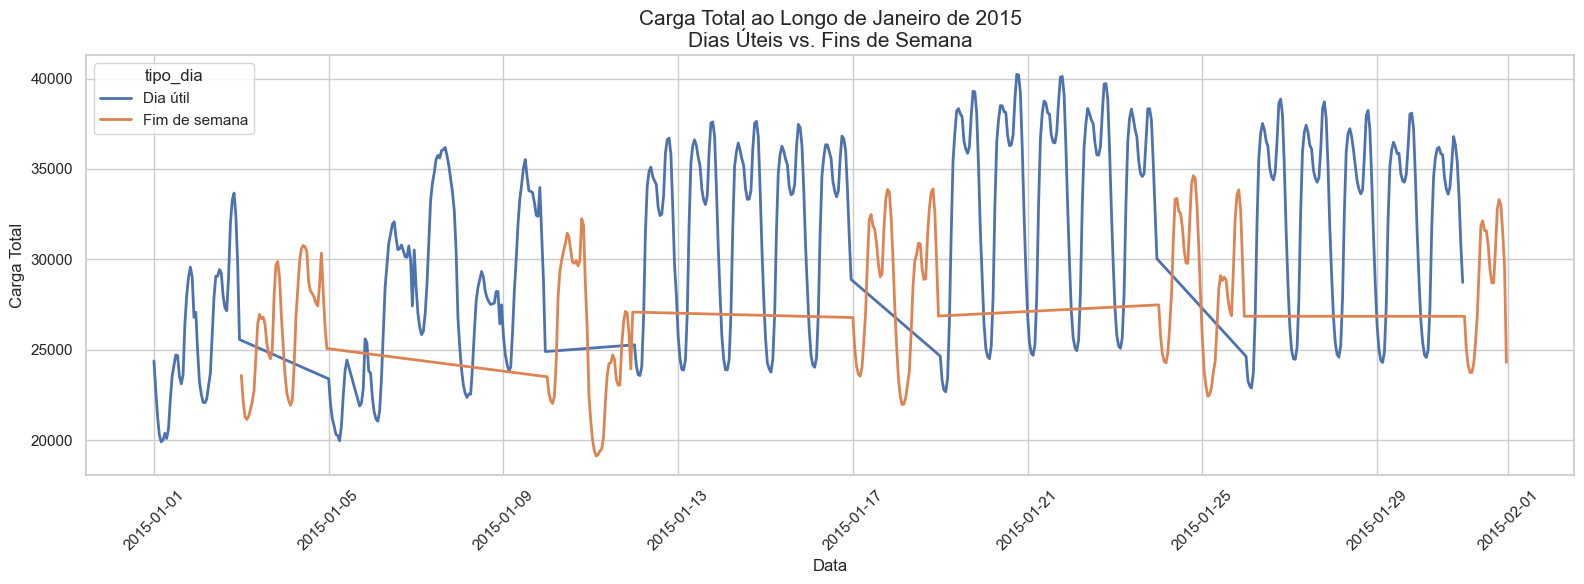

In [51]:
# LINE PLOT - CARGA TOTAL EM 1 MÊS

# Ajustando a coluna de data
# Trazendo o índice de volta para uma coluna chamada 'time'
df_energia_4 = df_energia_4.reset_index()
df_clima_4 = df_clima_4.reset_index()

# AGORA SIM o seu código vai encontrar a coluna:
df_energia_4['time'] = pd.to_datetime(df_energia_4['time'], utc=True).dt.tz_localize(None)

# Filtrando janeiro de 2015
df_mes = df_energia_4[
    (df_energia_4["time"] >= "2015-01-01") &
    (df_energia_4["time"] < "2015-02-01")
].copy()

# Classificando os dias
df_mes["tipo_dia"] = df_mes["time"].dt.weekday.map(
    lambda x: "Fim de semana" if x >= 5 else "Dia útil"
)

# Estilo do gráfico
sns.set_style("whitegrid")
plt.figure(figsize=(16, 6))

sns.lineplot(
    data=df_mes,
    x="time",
    y="total load actual",
    hue="tipo_dia",
    linewidth=2
)

plt.title(
    "Carga Total ao Longo de Janeiro de 2015\nDias Úteis vs. Fins de Semana",
    fontsize=15
)
plt.xlabel("Data")
plt.ylabel("Carga Total")
plt.xticks(rotation=45)
plt.tight_layout()

# Gerando o nome do arquivo para salvamento
filename = f"4.1_carga_uteis_fds.svg"
filepath = os.path.join(folder, filename)

# Salvando (sempre antes do plt.show())
plt.savefig(filepath, format='svg')

plt.show()

<div style="color: blue;">
    
## 4.2 - Correlação Entre Variáveis Climaticas - Heatmap

<div style="color: blue;">
    
Observa-se que as fontes de geração renovável são as mais influenciadas pelas condições climáticas. A geração solar apresenta correlação positiva moderada com a temperatura (0,42), indicando que dias mais quentes tendem a coincidir com maior produção solar. Por outro lado, a umidade possui forte correlação negativa com a geração solar (-0,58), sugerindo que condições mais úmidas reduzem significativamente sua produção, possivelmente devido à maior presença de nuvens e menor incidência de radiação solar.

A geração eólica apresenta correlação positiva com a velocidade do vento (0,32), como esperado, já que ventos mais intensos aumentam a produção de energia eólica. Também há uma leve relação positiva entre nebulosidade e geração eólica (0,12), o que pode indicar que condições climáticas mais instáveis favorecem ventos mais fortes.

As fontes fósseis, nucleares e parte da geração hidrelétrica apresentam correlações muito próximas de zero com as variáveis climáticas. Isso indica que essas formas de geração são relativamente independentes das condições meteorológicas e costumam operar de maneira mais constante ao longo do tempo.

Entre todas as relações observadas, a mais forte do gráfico é a correlação negativa entre umidade e geração solar, reforçando que a produção de energia solar é a mais sensível às variações do clima.

In [52]:
# HEATMAP DE CORRELAÇÃO
# Relação entre variáveis climáticas e tipos de geração
# Ajustando as colunas de data

df_energia_4["time"] = pd.to_datetime(df_energia_4["time"], utc=True).dt.tz_convert(None)
df_clima_4["dt_iso"] = pd.to_datetime(df_clima_4["dt_iso"], utc=True).dt.tz_convert(None)

# Selecionando apenas as colunas climáticas numéricas

colunas_clima = [
    "temp",
    "pressure",
    "humidity",
    "wind_speed",
    "clouds_all"
]

# Como existem várias cidades no df_clima_4,
# vamos tirar a média por horário
df_clima_4_media = (
    df_clima_4
    .groupby("dt_iso")[colunas_clima]
    .mean()
    .reset_index()
)

# Selecionando os tipos de geração de energia

colunas_energia = [
    "generation fossil gas",
    "generation fossil hard coal",
    "generation fossil oil",
    "generation hydro run-of-river and poundage",
    "generation hydro water reservoir",
    "generation nuclear",
    "generation solar",
    "generation wind onshore"
]

# Mantendo apenas data + colunas desejadas
df_energia_4_corr = df_energia_4[["time"] + colunas_energia].copy()


# Juntando clima e energia pela data/hora

df_merge = pd.merge(
    df_energia_4_corr,
    df_clima_4_media,
    left_on="time",
    right_on="dt_iso",
    how="inner"
)

# Removendo a coluna duplicada de data
df_merge.drop(columns="dt_iso", inplace=True)

# Calculando a matriz de correlação

corr = df_merge[colunas_energia + colunas_clima].corr()

# Queremos apenas:
# linhas = variáveis climáticas
# colunas = tipos de geração
corr_filtrada = corr.loc[colunas_clima, colunas_energia]


# Plotando o heatmap

plt.figure(figsize=(14, 6))

sns.heatmap(
    corr_filtrada,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlação entre Variáveis Climáticas e Tipos de Geração de Energia",
    fontsize=15,
    pad=15
)

plt.xlabel("Tipo de geração")
plt.ylabel("Variável climática")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

# Gerando o nome do arquivo para salvamento
filename = f"4.2_correlacao_clima_geracao.svg"
filepath = os.path.join(folder, filename)

# Salvando (sempre antes do plt.show())
plt.savefig(filepath, format='svg')

plt.show()

KeyError: 'dt_iso'

<div style="color: blue;">
    
## 4.3 - Demanda de Energia por Hora - Boxplot

### Referências Bibliográficas

KUHN, M.; JOHNSON, K. **Feature Engineering and Selection**: A Practical Approach for Predictive Models. Boca Raton: CRC Press, 2019.